# TopoMetry Integration Utilities — Demonstration

This notebook demonstrates the high-level integration API introduced in TopoMetry:

- `tp.sc.prepare_for_integration` — normalize and select HVGs in-place
- `tp.sc.run_cca_integration` — CCA-anchor batch correction (Seurat v3-style)
- `tp.sc.fit_adata` — fit TopOGraph and compute 2-D projections
- `tp.sc.compute_all_integration_metrics` — evaluate integration quality
- `tp.sc.save_cca_reference` / `tp.sc.load_cca_reference` — persist a reference
- `tp.sc.prepare_for_mapping` — prepare query data for mapping
- `tp.sc.find_mapping_order` — rank queries by similarity to reference
- `tp.sc.map_to_cca_reference` — map unseen batches to a frozen reference

**Dataset:** `Immune_ALL_human.h5ad` from the scIB benchmark  
(Luecken et al., 2022) — 33,506 cells, 10 batches, 16 immune cell types.

## 1. Load packages and data

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scanpy as sc
import anndata as ad
import topo as tp

sc.settings.verbosity = 1
print(f'scanpy {sc.__version__}  |  topo {tp.__version__}')

scanpy 1.10.3  |  topo 1.0.2


In [2]:
# Load the scIB benchmark dataset
# adata.X  : log-normalised expression (max ≈ 12)  — ready to use as-is
# adata.layers['counts'] : raw counts (integer, some batches are TPM/FPKM)
adata = ad.read_h5ad('Immune_ALL_human.h5ad')

# Add a 'cell_type' alias for the ground-truth annotation column
adata.obs['cell_type'] = adata.obs['final_annotation'].copy()

print(adata)
print(f"\nBatches  : {sorted(adata.obs['batch'].unique())}")
print(f"Cell types: {sorted(adata.obs['cell_type'].unique())}")
print(f"adata.X max = {adata.X.max():.3f}  (already log-normalised)")

AnnData object with n_obs × n_vars = 33506 × 12303
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue', 'cell_type'
    layers: 'counts'

Batches  : ['10X', 'Freytag', 'Oetjen_A', 'Oetjen_P', 'Oetjen_U', 'Sun_sample1_CS', 'Sun_sample2_KC', 'Sun_sample3_TB', 'Sun_sample4_TC', 'Villani']
Cell types: ['CD10+ B cells', 'CD14+ Monocytes', 'CD16+ Monocytes', 'CD20+ B cells', 'CD4+ T cells', 'CD8+ T cells', 'Erythrocytes', 'Erythroid progenitors', 'HSPCs', 'Megakaryocyte progenitors', 'Monocyte progenitors', 'Monocyte-derived dendritic cells', 'NK cells', 'NKT cells', 'Plasma cells', 'Plasmacytoid dendritic cells']
adata.X max = 12.041  (already log-normalised)


In [3]:
# Colour palettes — shared across all plots in this notebook
# One colour per batch (10 total)
batch_palette = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'
]
# One colour per cell type (16 total)
ct_palette = [
    '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231',
    '#911eb4', '#42d4f4', '#f032e6', '#bfef45', '#fabed4',
    '#469990', '#dcbeff', '#9a6324', '#fffac8', '#800000', '#aaffc3'
]

batch_order  = sorted(adata.obs['batch'].unique())
ct_order     = sorted(adata.obs['cell_type'].unique())
batch_colors = dict(zip(batch_order, batch_palette))
ct_colors    = dict(zip(ct_order,    ct_palette))

---
## 2. Workflow 1 — Full integration of all 10 batches

```
prepare_for_integration → run_cca_integration → fit_adata → compute_all_integration_metrics
```

### 2.1 Prepare data for integration

We tell `prepare_for_integration` that the data is **already log-normalised** (`input_type='lognorm'`), so no normalization is applied.  
HVG selection is still performed across batches to identify the best integration features.

In [4]:
# Work on a copy so the original adata is preserved for Workflow 2
adata_w1 = adata.copy()

tp.sc.prepare_for_integration(
    adata_w1,
    batch_key='batch',
    input_type='lognorm',   # data is already log-normalised
    select_hvgs=True,
    n_hvgs=2000,
)

n_feats = len(adata_w1.uns['integration_features'])
print(f"Selected {n_feats} integration features across 10 batches.")
print(f"adata_w1.layers: {list(adata_w1.layers.keys())}")

Selected 2000 integration features across 10 batches.
adata_w1.layers: ['counts', 'lognorm']


### 2.2 Run CCA integration

In [5]:
adata_int = tp.sc.run_cca_integration(
    adata_w1,
    batch_key='batch',
    n_components=30,
    scale_output=True,   # .X will be z-scored (ready for TopOGraph)
    n_jobs=-1,
)

log = adata_int.uns['cca_integration']
print(f"Integrated {log['n_datasets']} batches, {log['n_features']} features")
print(f"Anchors (raw → filtered) per merge step:")
for i, (r, f) in enumerate(zip(log['n_anchors_raw_per_merge'],
                                log['n_anchors_filt_per_merge'])):
    print(f"  merge {i+1:2d}: {r:5d} → {f:5d}")
print()
print(adata_int)

Integrated 10 batches, 2000 features
Anchors (raw → filtered) per merge step:
  merge  1: 52040 → 11981
  merge  2: 32442 →  8079
  merge  3: 146887 → 35527
  merge  4: 57757 → 33248
  merge  5: 58883 → 35815
  merge  6: 15079 →  2630
  merge  7: 122822 → 26700
  merge  8: 54647 → 41340
  merge  9: 72411 → 46651

AnnData object with n_obs × n_vars = 33506 × 2000
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue', 'cell_type'
    uns: 'cca_integration'
    obsm: 'X_cca'
    varm: 'cca_loadings'
    layers: 'counts', 'lognorm', 'original', 'corrected'


### 2.3 Fit TopOGraph and compute 2-D projections

In [6]:
tg_w1 = tp.sc.fit_adata(
    adata_int,
    projections=('MAP', 'PaCMAP'),
    do_leiden=True,
    leiden_resolutions=(0.3, 0.8),
    n_jobs=-1,
)
print("TopOGraph fitted. Available obsm keys:")
print([k for k in adata_int.obsm.keys()])

TopOGraph fitted. Available obsm keys:
['X_cca', 'X_ms_spectral_scaffold', 'X_spectral_scaffold', 'X_msTopoMAP', 'X_TopoMAP', 'X_msTopoPaCMAP', 'X_TopoPaCMAP']


### 2.4 Visualise — TopoMAP coloured by batch and cell type

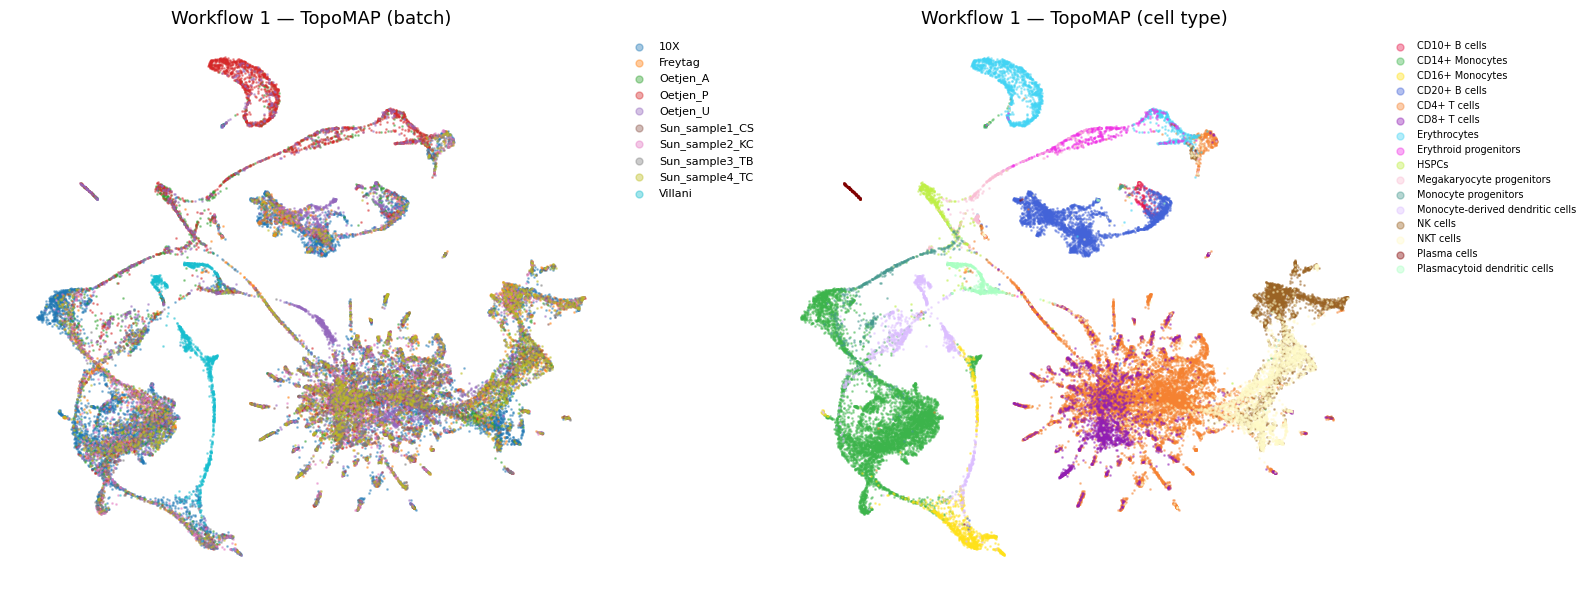

Saved w1_topomap.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

emb = adata_int.obsm['X_msTopoMAP']

# Batch
for batch in batch_order:
    mask = adata_int.obs['batch'] == batch
    axes[0].scatter(
        emb[mask, 0], emb[mask, 1],
        c=batch_colors[batch], s=1, alpha=0.4, label=batch, rasterized=True
    )
axes[0].set_title('Workflow 1 — TopoMAP (batch)', fontsize=13)
axes[0].legend(markerscale=5, bbox_to_anchor=(1.01, 1), loc='upper left',
               fontsize=8, frameon=False)
axes[0].axis('off')

# Cell type
for ct in ct_order:
    mask = adata_int.obs['cell_type'] == ct
    axes[1].scatter(
        emb[mask, 0], emb[mask, 1],
        c=ct_colors[ct], s=1, alpha=0.4, label=ct, rasterized=True
    )
axes[1].set_title('Workflow 1 — TopoMAP (cell type)', fontsize=13)
axes[1].legend(markerscale=5, bbox_to_anchor=(1.01, 1), loc='upper left',
               fontsize=7, frameon=False)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('w1_topomap.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved w1_topomap.png")

### 2.5 Integration quality metrics

In [8]:
# Subset original adata to the integration features for a fair comparison
features_w1 = list(adata_int.var_names)
adata_uncorr_w1 = adata_w1[:, features_w1].copy()
# Make sure batch column is present
if 'batch' not in adata_uncorr_w1.obs.columns:
    adata_uncorr_w1.obs['batch'] = adata_w1.obs['batch']

metrics_w1 = tp.sc.compute_all_integration_metrics(
    {
        'uncorrected': adata_uncorr_w1,
        'integrated':  adata_int,
    },
    batch_key='batch',
    cell_type_key='cell_type',
    cluster_key='topo_clusters',
    k=30,
    n_jobs=-1,
)

print("=== Workflow 1 — Integration metrics ===")
print(metrics_w1.to_string(float_format='{:.4f}'.format))

=== Workflow 1 — Integration metrics ===
            uncorrected  integrated
knn_purity       0.8427      0.8401
knn_mixing       0.4371      0.6771
ilisi            1.9674      4.0300
clisi            1.0700      1.0705
ari                 NaN      0.3050
nmi                 NaN      0.5788


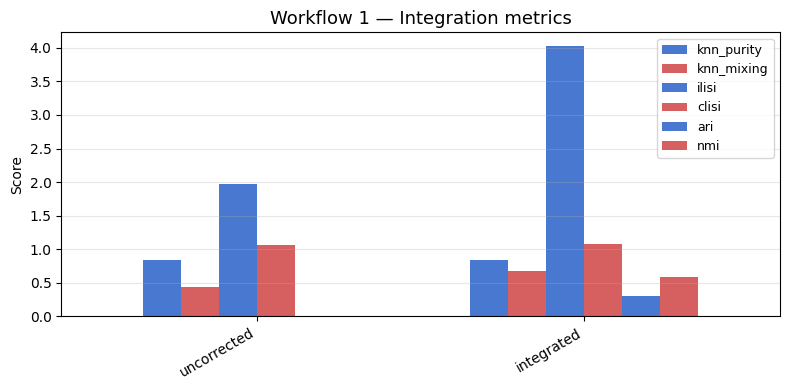

In [9]:
# Bar chart of metrics
fig, ax = plt.subplots(figsize=(8, 4))
metrics_w1.T.plot(
    kind='bar', ax=ax, width=0.7,
    color=['#4878CF', '#D65F5F']
)
ax.set_title('Workflow 1 — Integration metrics', fontsize=13)
ax.set_ylabel('Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('w1_metrics.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 3. Workflow 2 — Reference integration + sequential query mapping

Here we:
1. Integrate **6 batches** to build a reference atlas.
2. **Save** the reference to disk (for reproducibility / re-use).
3. **Prepare** the 4 held-out query batches.
4. **Find the optimal mapping order** (most similar to reference first).
5. **Map** all 4 queries sequentially, collecting intermediate atlases.
6. Fit TopOGraph on the final atlas and evaluate metrics.

```
prepare_for_integration(ref) → run_cca_integration(ref) → save_cca_reference
prepare_for_mapping(queries) → find_mapping_order → map_to_cca_reference
fit_adata(atlas) → compute_all_integration_metrics
```

### 3.1 Define reference and query batches

In [10]:
REF_BATCHES   = ['10X', 'Freytag', 'Oetjen_A', 'Oetjen_P',
                 'Sun_sample1_CS', 'Sun_sample2_KC']
QUERY_BATCHES = ['Oetjen_U', 'Sun_sample3_TB', 'Sun_sample4_TC', 'Villani']

print(f"Reference batches ({len(REF_BATCHES)}): {REF_BATCHES}")
print(f"Query batches    ({len(QUERY_BATCHES)}): {QUERY_BATCHES}")

adata_ref_raw = adata[adata.obs['batch'].isin(REF_BATCHES)].copy()
adata_queries_raw = [
    adata[adata.obs['batch'] == b].copy() for b in QUERY_BATCHES
]

print(f"\nReference cells : {adata_ref_raw.n_obs:,}")
for b, q in zip(QUERY_BATCHES, adata_queries_raw):
    print(f"  Query '{b}': {q.n_obs:,} cells")

Reference batches (6): ['10X', 'Freytag', 'Oetjen_A', 'Oetjen_P', 'Sun_sample1_CS', 'Sun_sample2_KC']
Query batches    (4): ['Oetjen_U', 'Sun_sample3_TB', 'Sun_sample4_TC', 'Villani']



Reference cells : 23,931
  Query 'Oetjen_U': 3,730 cells
  Query 'Sun_sample3_TB': 2,403 cells
  Query 'Sun_sample4_TC': 2,420 cells
  Query 'Villani': 1,022 cells


### 3.2 Prepare and integrate the reference

In [11]:
tp.sc.prepare_for_integration(
    adata_ref_raw,
    batch_key='batch',
    input_type='lognorm',
    select_hvgs=True,
    n_hvgs=2000,
)
n_feats_ref = len(adata_ref_raw.uns['integration_features'])
print(f"Selected {n_feats_ref} integration features for the reference.")

Selected 2000 integration features for the reference.


In [12]:
adata_ref = tp.sc.run_cca_integration(
    adata_ref_raw,
    batch_key='batch',
    n_components=30,
    scale_output=True,
    n_jobs=-1,
)

log_ref = adata_ref.uns['cca_integration']
print(f"Reference: {log_ref['n_datasets']} batches, {log_ref['n_features']} features")
print(f"Anchors (raw → filtered) per merge step:")
for i, (r, f) in enumerate(zip(log_ref['n_anchors_raw_per_merge'],
                                log_ref['n_anchors_filt_per_merge'])):
    print(f"  merge {i+1:2d}: {r:5d} → {f:5d}")

Reference: 6 batches, 2000 features
Anchors (raw → filtered) per merge step:
  merge  1: 51971 → 12070
  merge  2: 32460 →  7893
  merge  3: 145767 → 34570
  merge  4: 40885 → 21460
  merge  5: 161230 → 32093


### 3.3 Save the reference to disk

In [13]:
REFERENCE_PATH = '/tmp/immune_cca_reference.h5ad'

tp.sc.save_cca_reference(adata_ref, REFERENCE_PATH)
print(f"Reference saved to {REFERENCE_PATH}")

# Demonstrate round-trip: load it back
adata_ref_loaded = tp.sc.load_cca_reference(REFERENCE_PATH)
print(f"Loaded reference: {adata_ref_loaded.shape}, "
      f"CCA fields present: "
      f"varm['cca_loadings']={adata_ref_loaded.varm['cca_loadings'].shape}, "
      f"obsm['X_cca']={adata_ref_loaded.obsm['X_cca'].shape}")

Reference saved to /tmp/immune_cca_reference.h5ad


Loaded reference: (23931, 2000), CCA fields present: varm['cca_loadings']=(2000, 30), obsm['X_cca']=(23931, 30)


### 3.4 Prepare query datasets for mapping

In [14]:
tp.sc.prepare_for_mapping(
    adata_queries_raw,   # list of 4 query AnnDatas
    adata_ref,           # reference (for feature overlap check)
    batch_key='batch',
    input_type='lognorm',
)

for b, q in zip(QUERY_BATCHES, adata_queries_raw):
    shared = sum(g in set(adata_ref.var_names) for g in q.var_names)
    print(f"  '{b}': {shared}/{adata_ref.n_vars} reference features covered")

  'Oetjen_U': 2000/2000 reference features covered


  'Sun_sample3_TB': 2000/2000 reference features covered


  'Sun_sample4_TC': 2000/2000 reference features covered


  'Villani': 2000/2000 reference features covered


### 3.5 Find the optimal mapping order

In [15]:
mapping_order = tp.sc.find_mapping_order(
    adata_ref,
    adata_queries_raw,
    n_components=10,
    k=5,
    n_jobs=-1,
)

print("Optimal mapping order (most → least similar to reference):")
for rank, idx in enumerate(mapping_order):
    print(f"  {rank+1}. {QUERY_BATCHES[idx]}")

Optimal mapping order (most → least similar to reference):
  1. Oetjen_U
  2. Sun_sample3_TB
  3. Sun_sample4_TC
  4. Villani


### 3.6 Map queries sequentially to the reference

In [16]:
adata_atlas, steps = tp.sc.map_to_cca_reference(
    adata_queries_raw,    # list of query AnnDatas
    adata_ref,            # frozen reference (CCA fields kept intact)
    mode='query_only',
    mapping_order=mapping_order,
    sequential_topometry=False,   # TopOGraph fitted once on the final atlas
    return_intermediates=True,    # collect atlas at each step
    n_jobs=-1,
)

print(f"Final atlas: {adata_atlas.shape}")
print(f"Intermediate steps: {list(steps.keys())}")
print(f"adata_atlas.obs['batch'] value counts:")
print(adata_atlas.obs['batch'].value_counts())

Final atlas: (33506, 2000)
Intermediate steps: ['step_0', 'step_1', 'step_2', 'step_3']
adata_atlas.obs['batch'] value counts:
batch
10X               10727
Oetjen_U           3730
Freytag            3347
Oetjen_P           3265
Oetjen_A           2586
Sun_sample4_TC     2420
Sun_sample3_TB     2403
Sun_sample2_KC     2281
Sun_sample1_CS     1725
Villani            1022
Name: count, dtype: int64


### 3.7 Fit TopOGraph on the final atlas

In [17]:
tg_atlas = tp.sc.fit_adata(
    adata_atlas,
    projections=('MAP', 'PaCMAP'),
    do_leiden=True,
    leiden_resolutions=(0.3, 0.8),
    n_jobs=-1,
)
print("TopOGraph fitted on the full atlas.")
print([k for k in adata_atlas.obsm.keys()])

TopOGraph fitted on the full atlas.
['X_ms_spectral_scaffold', 'X_spectral_scaffold', 'X_msTopoMAP', 'X_TopoMAP', 'X_msTopoPaCMAP', 'X_TopoPaCMAP']


### 3.8 Visualise — TopoMAP of the full atlas

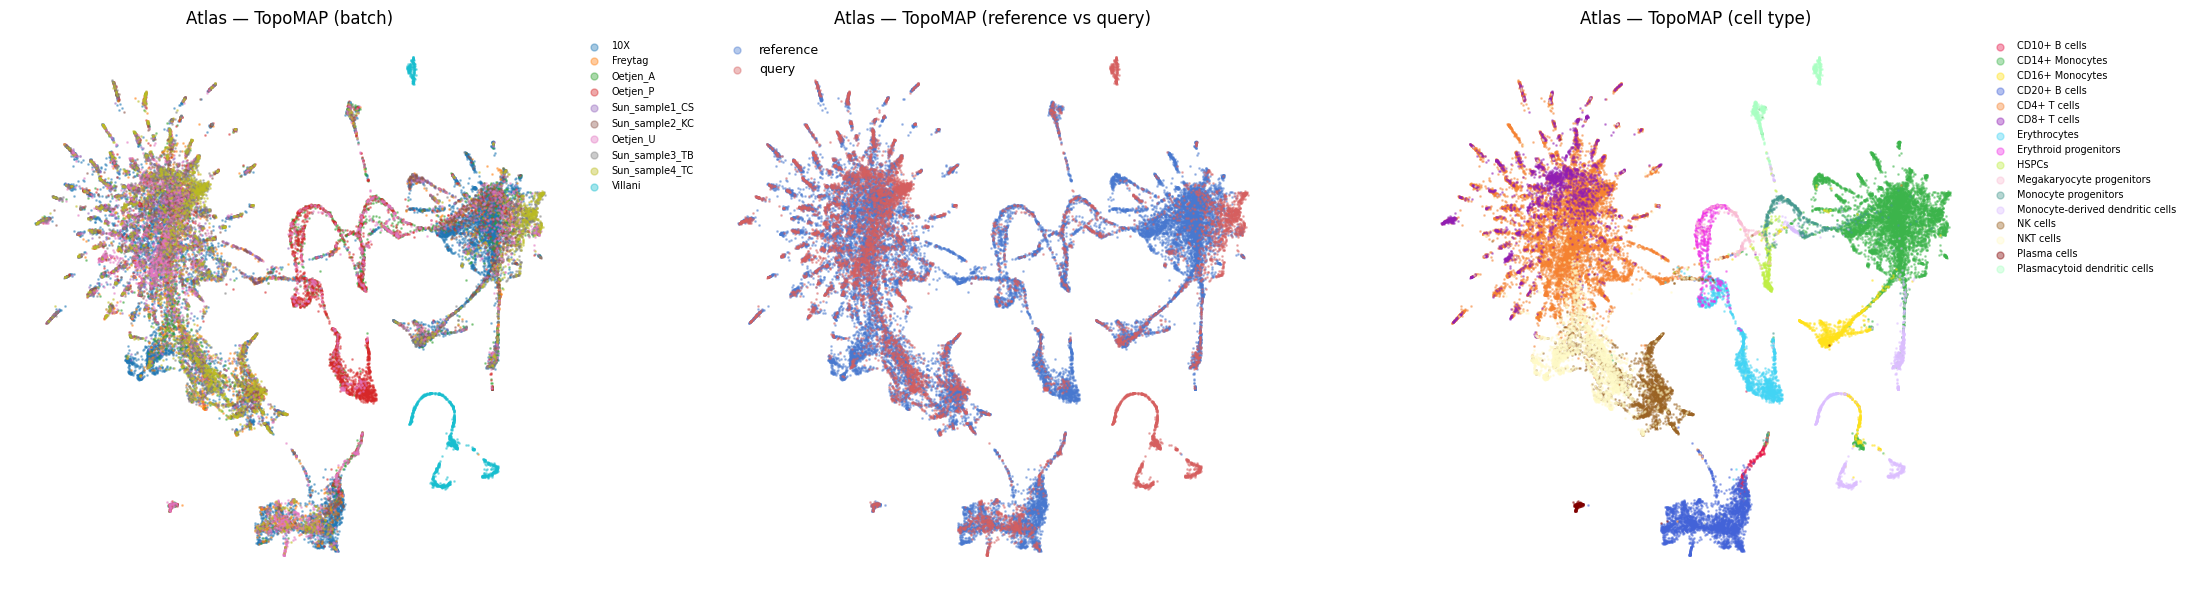

Saved w2_atlas_topomap.png


In [18]:
# Mark reference vs query cells for clarity
adata_atlas.obs['origin'] = np.where(
    adata_atlas.obs['batch'].isin(REF_BATCHES), 'reference', 'query')

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
emb2 = adata_atlas.obsm['X_msTopoMAP']

# Batch
all_batches = REF_BATCHES + QUERY_BATCHES
all_colors  = dict(zip(all_batches, batch_palette[:len(all_batches)]))
for batch in all_batches:
    mask = adata_atlas.obs['batch'] == batch
    axes[0].scatter(
        emb2[mask, 0], emb2[mask, 1],
        c=all_colors[batch], s=1, alpha=0.4, label=batch, rasterized=True
    )
axes[0].set_title('Atlas — TopoMAP (batch)', fontsize=12)
axes[0].legend(markerscale=5, bbox_to_anchor=(1.01, 1), loc='upper left',
               fontsize=7, frameon=False)
axes[0].axis('off')

# Reference vs query
origin_colors = {'reference': '#4878CF', 'query': '#D65F5F'}
for origin, col in origin_colors.items():
    mask = adata_atlas.obs['origin'] == origin
    axes[1].scatter(
        emb2[mask, 0], emb2[mask, 1],
        c=col, s=1, alpha=0.4, label=origin, rasterized=True
    )
axes[1].set_title('Atlas — TopoMAP (reference vs query)', fontsize=12)
axes[1].legend(markerscale=5, loc='upper left', fontsize=9, frameon=False)
axes[1].axis('off')

# Cell type
atlas_ct_order = sorted(adata_atlas.obs['cell_type'].dropna().unique())
atlas_ct_cols  = dict(zip(atlas_ct_order, ct_palette[:len(atlas_ct_order)]))
for ct in atlas_ct_order:
    mask = adata_atlas.obs['cell_type'] == ct
    axes[2].scatter(
        emb2[mask, 0], emb2[mask, 1],
        c=atlas_ct_cols[ct], s=1, alpha=0.4, label=ct, rasterized=True
    )
axes[2].set_title('Atlas — TopoMAP (cell type)', fontsize=12)
axes[2].legend(markerscale=5, bbox_to_anchor=(1.01, 1), loc='upper left',
               fontsize=7, frameon=False)
axes[2].axis('off')

plt.tight_layout()
plt.savefig('w2_atlas_topomap.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved w2_atlas_topomap.png")

### 3.9 Integration quality metrics — full comparison table

We compare:
- **uncorrected** — raw lognorm, no integration
- **reference** — 6-batch integrated reference
- **step_0 … step_3** — atlas after each sequential mapping step
- **final_atlas** — all 10 batches

In [19]:
# Uncorrected baseline: original lognorm data, same features as the reference
features_ref = list(adata_ref.var_names)
adata_uncorr_w2 = adata[:, [g for g in features_ref if g in adata.var_names]].copy()

adata_dict_w2 = {
    'uncorrected': adata_uncorr_w2,
    'reference':   adata_ref,
}
# Add intermediate steps
for label in sorted(steps.keys()):
    step_idx = int(label.split('_')[1])
    query_name = QUERY_BATCHES[mapping_order[step_idx]]
    adata_dict_w2[f'{label} (+{query_name})'] = steps[label]
adata_dict_w2['final_atlas'] = adata_atlas

metrics_w2 = tp.sc.compute_all_integration_metrics(
    adata_dict_w2,
    batch_key='batch',
    cell_type_key='cell_type',
    cluster_key='topo_clusters',
    k=30,
    n_jobs=-1,
)

print("=== Workflow 2 — Integration metrics ===")
print(metrics_w2.to_string(float_format='{:.4f}'.format))

=== Workflow 2 — Integration metrics ===
            uncorrected  reference  step_0 (+Oetjen_U)  step_1 (+Sun_sample3_TB)  step_2 (+Sun_sample4_TC)  step_3 (+Villani)  final_atlas
knn_purity       0.8400     0.7209              0.7221                    0.7270                    0.7293             0.7512       0.8462
knn_mixing       0.4421     0.8156              0.8413                    0.8533                    0.8630             0.8640       0.6535
ilisi            1.9518     2.6357              2.6615                    2.7616                    2.9197             2.9430       3.5237
clisi            1.0700     1.1413              1.1413                    1.1418                    1.1415             1.1403       1.0673
ari                 NaN        NaN                 NaN                       NaN                       NaN                NaN       0.3910
nmi                 NaN        NaN                 NaN                       NaN                       NaN                NaN

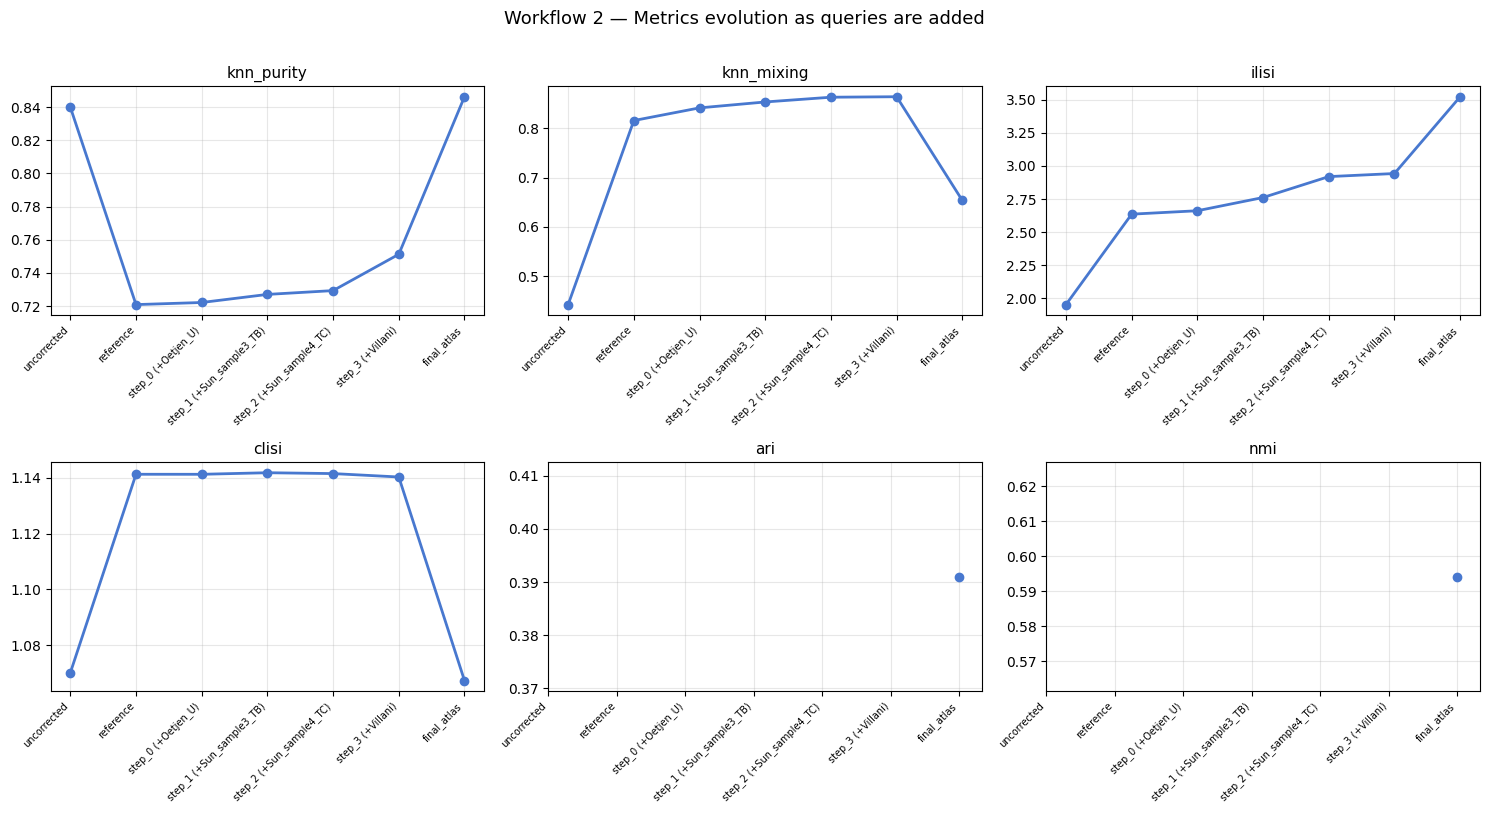

In [20]:
# Line chart showing how metrics evolve as queries are added
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

metric_names = [m for m in metrics_w2.index if m in
                ['knn_purity', 'knn_mixing', 'ilisi', 'clisi', 'ari', 'nmi']]
col_labels = list(metrics_w2.columns)

for ax, metric in zip(axes, metric_names):
    vals = metrics_w2.loc[metric].values.astype(float)
    ax.plot(range(len(col_labels)), vals, 'o-', color='#4878CF', linewidth=2)
    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, rotation=45, ha='right', fontsize=7)
    ax.set_title(metric, fontsize=11)
    ax.grid(alpha=0.3)

plt.suptitle('Workflow 2 — Metrics evolution as queries are added',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('w2_metrics_evolution.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Summary

| | Workflow 1 (full, 10 batches) | Workflow 2 (final atlas, 10 batches) |
|---|---|---|
| API | `prepare_for_integration` + `run_cca_integration` | `prepare_for_integration` + `run_cca_integration` (6 batches) + `map_to_cca_reference` (4 batches) |
| Batch mixing (iLISI ↑) | *(from table above)* | *(from table above)* |
| Cell-type preservation (cLISI ↓) | *(from table above)* | *(from table above)* |

Both workflows use the same underlying CCA-anchor correction.
The sequential mapping workflow is suited for incrementally extending a stable reference atlas.